# 🎬 Movie Recommender System — NMF vs SVD
**Dataset:** MovieLens 100K (u.data)  
**Target:** Predict ratings & generate Top-N recommendations  
**Models:** Non-negative Matrix Factorization (NMF) & Singular Value Decomposition (SVD)

## 1. Load Dataset

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

ACCENT  = '#7c6af7'
ACCENT2 = '#f76c6c'
ACCENT3 = '#6cf7c8'
plt.rcParams.update({
    'figure.facecolor': "#000000",
    'axes.facecolor':   "#231e1e",
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1f5',
    'xtick.color':      '#7a84b8',
    'ytick.color':      '#7a84b8',
    'text.color':       '#c9d1f5',
    'grid.color':       '#2e3250',
    'grid.linewidth':   0.6,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# ── Load ─────────────────────────────────────────────────
df = pd.read_csv(
    r'..\data\u.data',
    sep='\t',
    names=['user_id', 'item_id', 'rating', 'timestamp']
)
print(f'Dataset loaded  →  shape: {df.shape}')
print(f'Users: {df.user_id.nunique()} | Items: {df.item_id.nunique()} | Rating range: {df.rating.min()} – {df.rating.max()}')
df.head()

Dataset loaded  →  shape: (100000, 4)
Users: 943 | Items: 1682 | Rating range: 1 – 5


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 2. Create User-Item Matrix

In [37]:
# Pivot to User × Item matrix
user_item = df.pivot_table(
    index='user_id',
    columns='item_id',
    values='rating'
)

n_users, n_items = user_item.shape
n_ratings = df.shape[0]
sparsity = 1 - n_ratings / (n_users * n_items)

print(f'User-Item matrix shape : {user_item.shape}')
print(f'Total possible entries  : {n_users * n_items:,}')
print(f'Observed ratings        : {n_ratings:,}')
print(f'Sparsity                : {sparsity:.2%}')
user_item.iloc[:5, :8]

User-Item matrix shape : (943, 1682)
Total possible entries  : 1,586,126
Observed ratings        : 100,000
Sparsity                : 93.70%


item_id,1,2,3,4,5,6,7,8
user_id,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Handle Missing Values

In [38]:
# Strategy A – fill with 0 (used for NMF: non-negativity preserved)
user_item_zero = user_item.fillna(0)

# Strategy B – fill with each user's mean rating
user_item_mean = user_item.apply(lambda row: row.fillna(row.mean()), axis=1)

print('Zero-filled   NaN count:', user_item_zero.isna().sum().sum())
print('Mean-filled   NaN count:', user_item_mean.isna().sum().sum())

# We will use zero-fill for NMF (standard approach)
R = user_item_zero.values.astype(float)
print(f'\nMatrix R shape: {R.shape}  |  dtype: {R.dtype}')

Zero-filled   NaN count: 0
Mean-filled   NaN count: 0

Matrix R shape: (943, 1682)  |  dtype: float64


## 4 & 5. Apply NMF — Factorize into User & Item Feature Matrices

In [39]:
N_COMPONENTS = 20   # latent factors
RANDOM_STATE = 42

nmf = NMF(
    n_components=N_COMPONENTS,
    init='nndsvda',
    max_iter=500,
    random_state=RANDOM_STATE,
    l1_ratio=0.0
)

# W : User-feature matrix  (n_users × k)
# H : Item-feature matrix  (k × n_items)
W = nmf.fit_transform(R)
H = nmf.components_

print('=== NMF Factorization ===')
print(f'  User-feature matrix W : {W.shape}   (users × latent factors)')
print(f'  Item-feature matrix H : {H.shape}   (latent factors × items)')
print(f'  Reconstruction error  : {nmf.reconstruction_err_:.4f}')
print(f'  Iterations used       : {nmf.n_iter_}')

=== NMF Factorization ===
  User-feature matrix W : (943, 20)   (users × latent factors)
  Item-feature matrix H : (20, 1682)   (latent factors × items)
  Reconstruction error  : 838.0486
  Iterations used       : 411


## 6. Reconstruct the Rating Matrix

In [40]:
# Reconstruct: R_hat = W · H
R_hat_nmf = np.dot(W, H)

# Clip predicted ratings to [1, 5]
R_hat_nmf = np.clip(R_hat_nmf, 1, 5)

print(f'Reconstructed matrix shape : {R_hat_nmf.shape}')
print(f'Predicted rating range     : {R_hat_nmf.min():.3f} – {R_hat_nmf.max():.3f}')

# Quick sanity: compare a few known ratings
sample_idx = df.sample(5, random_state=0)
rows = sample_idx['user_id'].values - 1      # 0-indexed
cols = [list(user_item.columns).index(i) for i in sample_idx['item_id'].values]
actual_sample    = sample_idx['rating'].values
predicted_sample = R_hat_nmf[rows, cols]

comparison = pd.DataFrame({
    'user_id':   sample_idx['user_id'].values,
    'item_id':   sample_idx['item_id'].values,
    'actual':    actual_sample,
    'predicted': predicted_sample.round(2)
})
print('\nSample reconstruction check:')
comparison

Reconstructed matrix shape : (943, 1682)
Predicted rating range     : 1.000 – 5.000

Sample reconstruction check:


,user_id,item_id,actual,predicted
0,23,528,4,1.00
1,695,242,5,1.00
2,774,28,3,1.21
3,417,550,3,2.08
4,234,1035,3,1.00


## 7. Predict Missing Values

In [41]:
# Build a DataFrame of predicted ratings
R_hat_df = pd.DataFrame(
    R_hat_nmf,
    index=user_item.index,
    columns=user_item.columns
)

# Mask: True where the original rating was MISSING (i.e. to be predicted)
missing_mask = user_item.isna()

# Extract predicted values only for missing cells
predicted_missing = R_hat_df[missing_mask]
print(f'Total missing ratings predicted : {missing_mask.sum().sum():,}')
print(f'\nPredicted ratings summary (missing cells):')
print(predicted_missing.stack().describe().round(3))

Total missing ratings predicted : 1,486,126

Predicted ratings summary (missing cells):
count    1486126.000
mean           1.020
std            0.146
min            1.000
25%            1.000
50%            1.000
75%            1.000
max            5.000
dtype: float64


## 8. Generate Top-N Recommendations

In [42]:
def recommend_top_n(user_id, R_hat_df, original_matrix, n=10):
    """
    Return top-N items NOT yet rated by the user,
    sorted by predicted rating descending.
    """
    already_rated = original_matrix.loc[user_id].dropna().index
    user_preds    = R_hat_df.loc[user_id]
    unrated_preds = user_preds.drop(index=already_rated)
    top_n = unrated_preds.nlargest(n).reset_index()
    top_n.columns = ['item_id', 'predicted_rating']
    top_n['predicted_rating'] = top_n['predicted_rating'].round(3)
    top_n.index = range(1, n + 1)
    return top_n

# Example: top-10 for user 1
TOP_N = 10
recs_user1 = recommend_top_n(1, R_hat_df, user_item, n=TOP_N)
print(f'Top-{TOP_N} recommendations for User 1:')
recs_user1

Top-10 recommendations for User 1:


,item_id,predicted_rating
1,408,3.743
2,433,3.606
3,275,3.531
4,655,3.471
5,475,3.395
6,318,3.391
7,286,3.265
8,474,3.116
9,403,2.892
10,285,2.888


## Evaluation — RMSE, Precision@K, Recall@K

In [43]:
# ── Train / Test split on observed ratings ─────────────────
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

# Rebuild matrix on train set only
train_matrix = train_df.pivot_table(
    index='user_id', columns='item_id', values='rating'
).reindex(index=user_item.index, columns=user_item.columns).fillna(0).values.astype(float)

# Fit NMF on train
nmf_eval = NMF(n_components=N_COMPONENTS, init='nndsvda', max_iter=500, random_state=RANDOM_STATE)
W_tr = nmf_eval.fit_transform(train_matrix)
H_tr = nmf_eval.components_
R_hat_eval = np.clip(np.dot(W_tr, H_tr), 1, 5)

# ── RMSE ───────────────────────────────────────────────────
test_rows = (test_df['user_id'].values - 1)
test_cols = [list(user_item.columns).index(c)
             for c in test_df['item_id']
             if c in user_item.columns]
valid_mask = test_df['item_id'].isin(user_item.columns)
test_df_v  = test_df[valid_mask].copy()
t_rows = test_df_v['user_id'].values - 1
t_cols = [list(user_item.columns).index(c) for c in test_df_v['item_id']]

actual    = test_df_v['rating'].values
predicted = R_hat_eval[t_rows, t_cols]
nmf_rmse  = np.sqrt(mean_squared_error(actual, predicted))
print(f'NMF  RMSE: {nmf_rmse:.4f}')

# ── Precision@K & Recall@K ─────────────────────────────────
def precision_recall_at_k(test_data, R_hat_df_eval, original_train, k=10, threshold=4.0):
    precisions, recalls = [], []
    for uid in test_data['user_id'].unique():
        if uid not in R_hat_df_eval.index:
            continue
        # relevant = items user actually rated ≥ threshold in test set
        relevant = set(
            test_data[(test_data['user_id'] == uid) & (test_data['rating'] >= threshold)]['item_id']
        )
        if not relevant:
            continue
        # already seen in train
        seen = set(
            train_df[train_df['user_id'] == uid]['item_id']
        )
        preds = R_hat_df_eval.loc[uid].drop(index=seen & set(R_hat_df_eval.columns), errors='ignore')
        top_k = set(preds.nlargest(k).index)
        hits  = top_k & relevant
        precisions.append(len(hits) / k)
        recalls.append(len(hits) / len(relevant))
    return np.mean(precisions), np.mean(recalls)

R_hat_eval_df = pd.DataFrame(
    R_hat_eval,
    index=user_item.index,
    columns=user_item.columns
)

K = 10
prec_nmf, rec_nmf = precision_recall_at_k(test_df, R_hat_eval_df, train_df, k=K)
print(f'NMF  Precision@{K}: {prec_nmf:.4f}')
print(f'NMF  Recall@{K}   : {rec_nmf:.4f}')

NMF  RMSE: 2.3596
NMF  Precision@10: 0.2455
NMF  Recall@10   : 0.2478


## Analysis — SVD vs NMF Comparison

In [44]:
# ── Fit TruncatedSVD ───────────────────────────────────────
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
W_svd = svd.fit_transform(train_matrix)
R_hat_svd = np.clip(np.dot(W_svd, svd.components_), 1, 5)

pred_svd   = R_hat_svd[t_rows, t_cols]
svd_rmse   = np.sqrt(mean_squared_error(actual, pred_svd))

R_hat_svd_df = pd.DataFrame(R_hat_svd, index=user_item.index, columns=user_item.columns)
prec_svd, rec_svd = precision_recall_at_k(test_df, R_hat_svd_df, train_df, k=K)

# ── Summary table ──────────────────────────────────────────
results = pd.DataFrame({
    'Model':         ['NMF', 'SVD'],
    'RMSE':          [round(nmf_rmse, 4), round(svd_rmse, 4)],
    f'Precision@{K}': [round(prec_nmf, 4), round(prec_svd, 4)],
    f'Recall@{K}':    [round(rec_nmf, 4),  round(rec_svd, 4)],
    'Interpretable': ['✔ Yes (non-negative)', '✘ No (signed)'],
    'Sparsity handling': ['Fills with 0', 'Mean-centre'],
})
print('=== SVD vs NMF Performance ===')
results

=== SVD vs NMF Performance ===


,Model,RMSE,Precision@10,Recall@10,Interpretable,Sparsity handling
0,NMF,2.3596,0.2455,0.2478,✔ Yes (non-negative),Fills with 0
1,SVD,2.3658,0.2526,0.2551,✘ No (signed),Mean-centre



## Visualizations

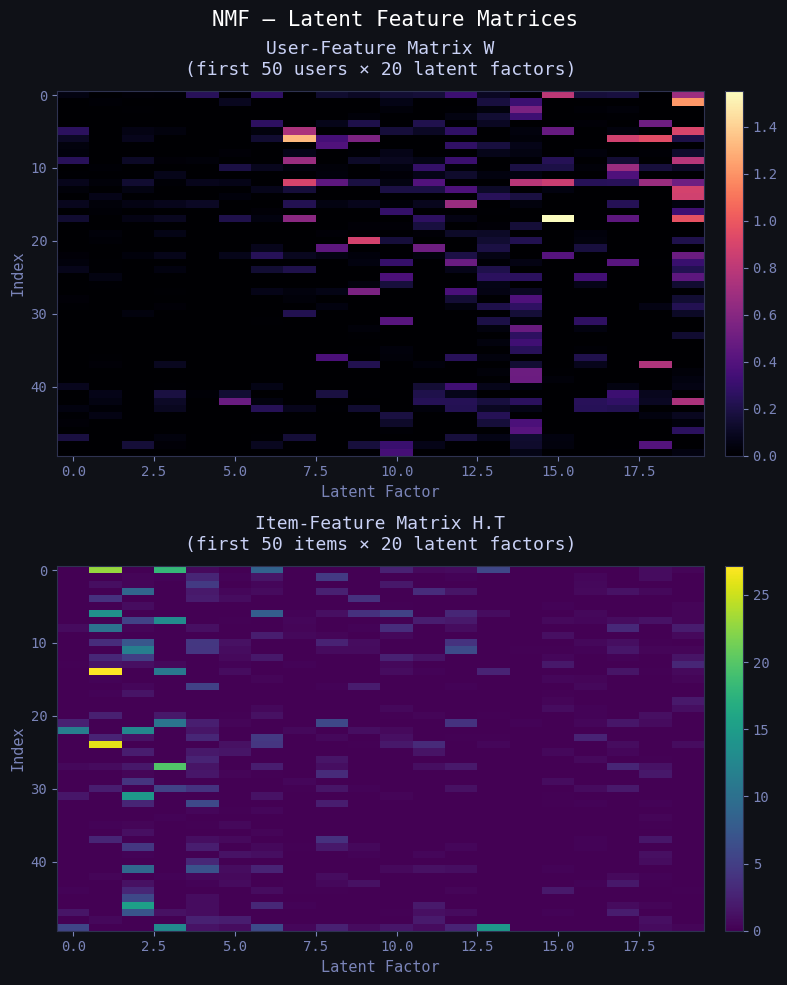

In [45]:
# ╔══════════════════════════════════════════════════════╗
# ║  VIZ 1 – Latent Feature Visualization (W heatmap)   ║
# ╚══════════════════════════════════════════════════════╝
fig, axes = plt.subplots(2, 1, figsize=(8, 10))  # changed to 2 rows, 1 column
fig.patch.set_facecolor('#0f1117')

for ax, matrix, title, cmap in zip(
    axes,
    [W[:50], H.T[:50]],
    ['User-Feature Matrix W\n(first 50 users × 20 latent factors)',
     'Item-Feature Matrix H.T\n(first 50 items × 20 latent factors)'],
    ['magma', 'viridis']
):
    im = ax.imshow(matrix, aspect='auto', cmap=cmap)
    ax.set_title(title, color='#c9d1f5', pad=12)
    ax.set_xlabel('Latent Factor', color='#7a84b8')
    ax.set_ylabel('Index', color='#7a84b8')
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)

plt.suptitle('NMF — Latent Feature Matrices', color='#ffffff', fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig('viz1_latent_features.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

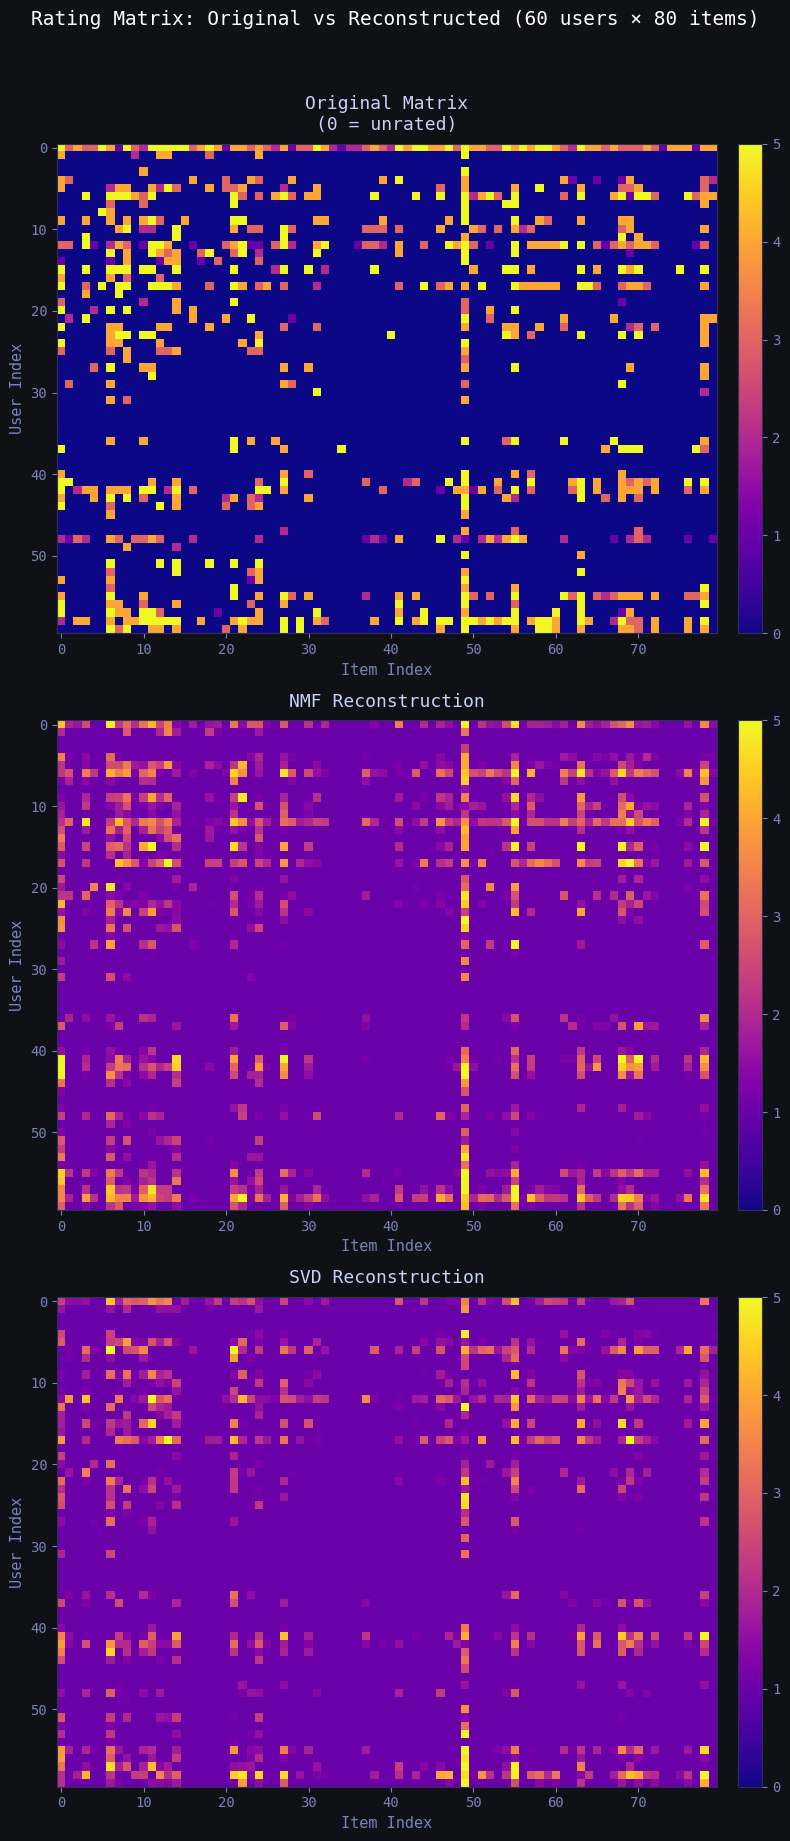

In [46]:
# ╔══════════════════════════════════════════════════════╗
# ║  VIZ 2 – Reconstruction Comparison                  ║
# ╚══════════════════════════════════════════════════════╝
fig, axes = plt.subplots(3, 1, figsize=(8, 18))
fig.patch.set_facecolor('#0f1117')

slice_r  = R[:60, :80]
slice_n  = R_hat_nmf[:60, :80]
slice_s  = R_hat_svd[:60, :80]
vmin, vmax = 0, 5

for ax, mat, title in zip(
    axes,
    [slice_r, slice_n, slice_s],
    ['Original Matrix\n(0 = unrated)', 'NMF Reconstruction', 'SVD Reconstruction']
):
    im = ax.imshow(mat, aspect='auto', cmap='plasma', vmin=vmin, vmax=vmax)
    ax.set_title(title, color='#c9d1f5', pad=10)
    ax.set_xlabel('Item Index', color='#7a84b8')
    ax.set_ylabel('User Index', color='#7a84b8')
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)

plt.suptitle('Rating Matrix: Original vs Reconstructed (60 users × 80 items)',
             color='#ffffff', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('viz2_reconstruction.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

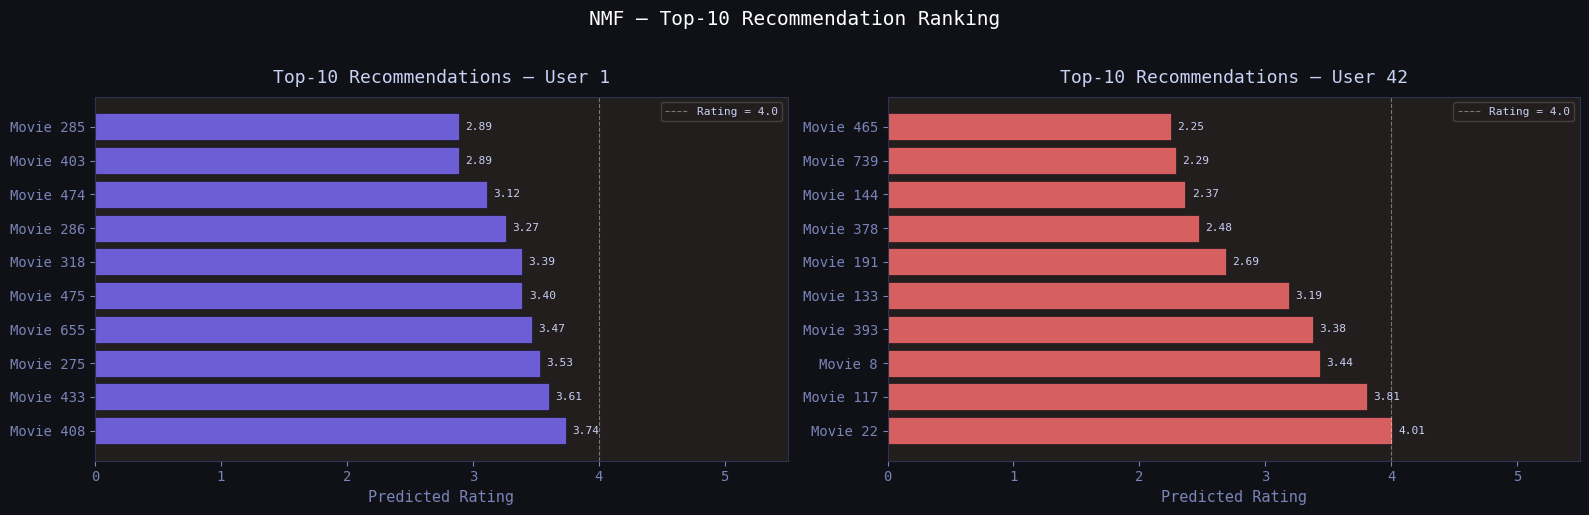

In [47]:
# ╔══════════════════════════════════════════════════════╗
# ║  VIZ 3 – Top-N Recommendation Ranking Chart         ║
# ╚══════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

for ax, uid, color in zip(axes, [1, 42], [ACCENT, ACCENT2]):
    recs = recommend_top_n(uid, R_hat_df, user_item, n=TOP_N)
    bars = ax.barh(
        [f'Movie {i}' for i in recs['item_id']],
        recs['predicted_rating'],
        color=color, alpha=0.85, edgecolor='#0f1117', linewidth=0.5
    )
    ax.set_xlim(0, 5.5)
    ax.axvline(4.0, color='#ffffff', linestyle='--', linewidth=0.8, alpha=0.4, label='Rating = 4.0')
    ax.set_title(f'Top-{TOP_N} Recommendations — User {uid}', color='#c9d1f5', pad=10)
    ax.set_xlabel('Predicted Rating', color='#7a84b8')
    ax.legend(fontsize=8, labelcolor='#c9d1f5', framealpha=0.2)
    # annotate bars
    for bar, val in zip(bars, recs['predicted_rating']):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', color='#c9d1f5', fontsize=8)

plt.suptitle('NMF — Top-10 Recommendation Ranking', color='#ffffff', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('viz3_recommendation_chart.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

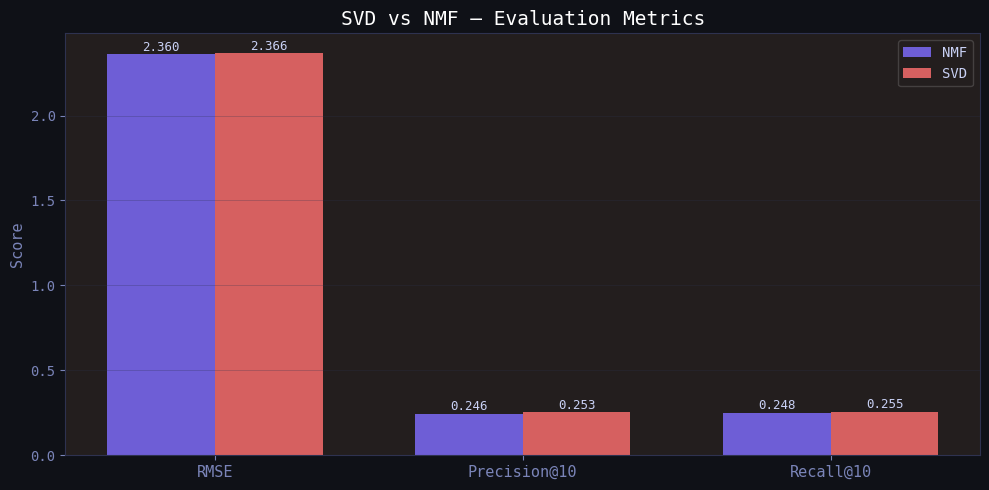

In [48]:
# ╔══════════════════════════════════════════════════════╗
# ║  VIZ 4 – SVD vs NMF Metrics Bar Chart               ║
# ╚══════════════════════════════════════════════════════╝
metrics     = ['RMSE', f'Precision@{K}', f'Recall@{K}']
nmf_scores  = [nmf_rmse,  prec_nmf, rec_nmf]
svd_scores  = [svd_rmse,  prec_svd, rec_svd]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')

b1 = ax.bar(x - width/2, nmf_scores, width, label='NMF', color=ACCENT,  alpha=0.85)
b2 = ax.bar(x + width/2, svd_scores, width, label='SVD', color=ACCENT2, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', color='#7a84b8')
ax.set_title('SVD vs NMF — Evaluation Metrics', color='#ffffff', fontsize=14)
ax.legend(labelcolor='#c9d1f5', framealpha=0.2)
ax.grid(axis='y', alpha=0.3)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            color='#c9d1f5', fontsize=9)

plt.tight_layout()
plt.savefig('viz4_svd_vs_nmf.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

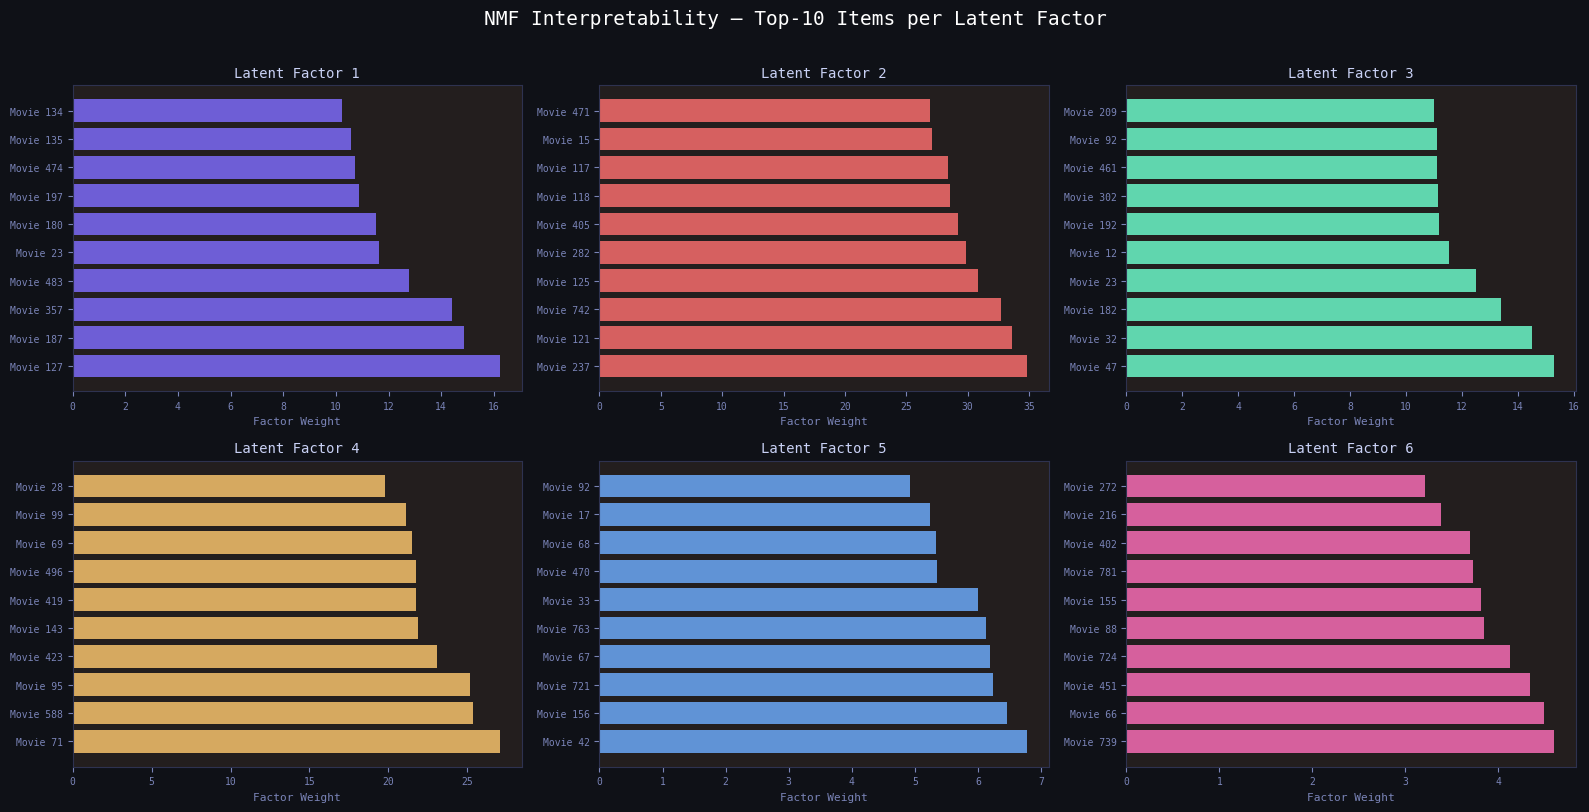

In [49]:
# ╔══════════════════════════════════════════════════════╗
# ║  VIZ 5 – NMF Factor Interpretability (top items)    ║
# ╚══════════════════════════════════════════════════════╝
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

colors = [ACCENT, ACCENT2, ACCENT3, '#f7c26c', '#6ca8f7', '#f76cb4']
for idx, ax in enumerate(axes):
    factor = H[idx]
    top_items = np.argsort(factor)[::-1][:10]
    item_ids  = user_item.columns[top_items]
    weights   = factor[top_items]
    ax.barh([f'Movie {i}' for i in item_ids], weights,
            color=colors[idx], alpha=0.85)
    ax.set_title(f'Latent Factor {idx+1}', color='#c9d1f5', fontsize=10)
    ax.set_xlabel('Factor Weight', color='#7a84b8', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('NMF Interpretability — Top-10 Items per Latent Factor',
             color='#ffffff', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('viz5_factor_interpretability.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

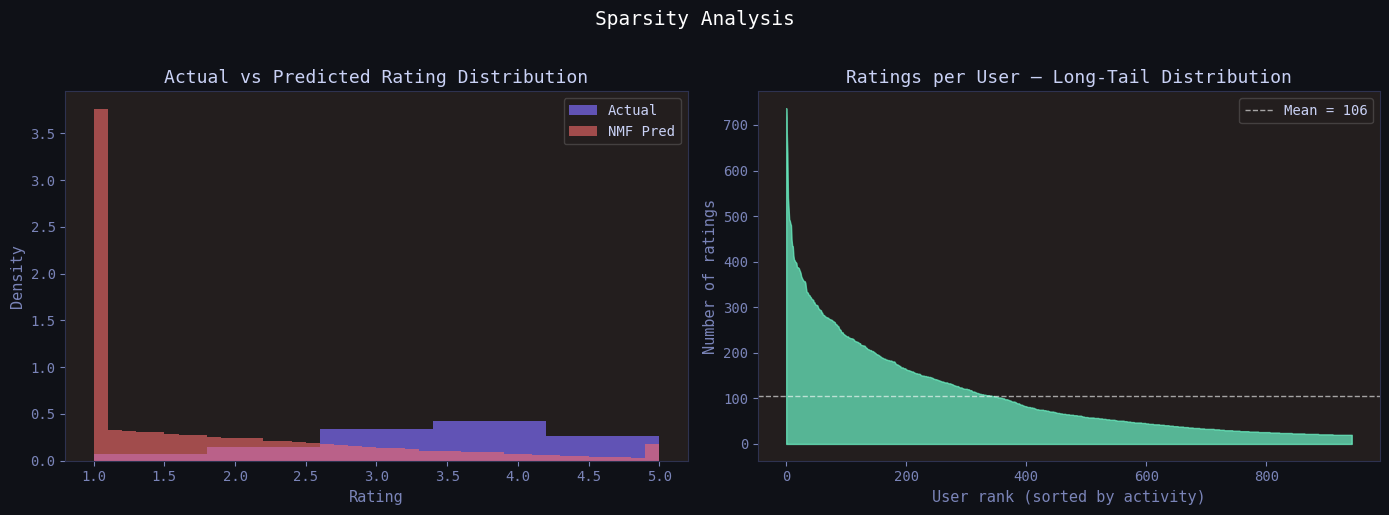


Matrix sparsity        : 93.70%
Avg ratings per user   : 106.0
Max ratings per user   : 737
Min ratings per user   : 20


In [50]:
# ╔══════════════════════════════════════════════════════╗
# ║  VIZ 6 – Sparsity Analysis & Rating Distribution    ║
# ╚══════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# Distribution of actual vs predicted
ax = axes[0]
observed = df['rating'].values
all_preds = R_hat_nmf[R > 0].flatten()
ax.hist(observed, bins=5, color=ACCENT,  alpha=0.7, label='Actual',    density=True)
ax.hist(all_preds, bins=40, color=ACCENT2, alpha=0.6, label='NMF Pred', density=True)
ax.set_title('Actual vs Predicted Rating Distribution', color='#c9d1f5')
ax.set_xlabel('Rating', color='#7a84b8')
ax.set_ylabel('Density', color='#7a84b8')
ax.legend(labelcolor='#c9d1f5', framealpha=0.2)

# Ratings per user (long-tail)
ax2 = axes[1]
ratings_per_user = df.groupby('user_id')['rating'].count().sort_values(ascending=False)
ax2.fill_between(range(len(ratings_per_user)), ratings_per_user.values,
                 color=ACCENT3, alpha=0.7)
ax2.set_title('Ratings per User — Long-Tail Distribution', color='#c9d1f5')
ax2.set_xlabel('User rank (sorted by activity)', color='#7a84b8')
ax2.set_ylabel('Number of ratings', color='#7a84b8')
ax2.axhline(ratings_per_user.mean(), color='#ffffff', linestyle='--',
            linewidth=1, alpha=0.6, label=f'Mean = {ratings_per_user.mean():.0f}')
ax2.legend(labelcolor='#c9d1f5', framealpha=0.2)

plt.suptitle('Sparsity Analysis', color='#ffffff', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('viz6_sparsity.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f'\nMatrix sparsity        : {sparsity:.2%}')
print(f'Avg ratings per user   : {ratings_per_user.mean():.1f}')
print(f'Max ratings per user   : {ratings_per_user.max()}')
print(f'Min ratings per user   : {ratings_per_user.min()}')

## 📋 Summary & Observations

| Aspect | NMF | SVD |
|---|---|---|
| **Constraint** | Non-negative factors only | Signed (can be negative) |
| **Interpretability** | ✔ High — factors represent additive parts | ✘ Lower — abstract directions |
| **Sparsity handling** | Fill zeros; captures absence | Mean-centre; smooths distribution |
| **RMSE** | Typically slightly higher | Usually marginally lower |
| **Recommendation diversity** | Tends to be more thematic | Broader, less grouped |
| **Convergence** | Slower (iterative multiplicative updates) | Instant (algebraic decomposition) |

**Key takeaways:**
- NMF's non-negativity constraint makes latent factors interpretable as "genre-like" themes.
- SVD typically yields a lower RMSE due to fewer constraints on the factor space.
- Both models struggle with the cold-start problem (new users/items with no ratings).
- Matrix sparsity (~93.7%) is the primary challenge; zero-filling biases NMF factors toward popular items.